In [ ]:
import sys
sys.path.append('..')  # go up one level to project/

from typing import Dict, Mapping, Sequence, Tuple
from pathlib import Path
from collections import Counter
import xml.etree.ElementTree as ET

# wordcloud of top labels across all movies, sized by global frequency.
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import numpy as np
from jen_reference.eyetracking_helper import *
import pandas as pd

label_map_path = '/hehe/projects/gaze-corrected-semantics/jen_reference/data/masks/label_map.txt'
xml_dir = Path('/hehe/projects/gaze-corrected-semantics/jen_reference/data/masks/segmentation-xmls/')
movies = [
    'test2',
    'train01', 'train02', 'train03', 'train04', 'train05',
    'train06', 'train07', 'train08', 'train09', 'train10',
]

In [21]:
import glob
import re
import re
import glob
import numpy as np
import pandas as pd

def lanczosfun(cutoff, t, window=3):
    t = np.asarray(t, dtype=float) * float(cutoff)
    val = np.zeros_like(t, dtype=float)

    # Evaluate only away from zero to avoid runtime warnings from 0/0;
    # fill t==0 explicitly with the analytic limit value 1.
    nz = t != 0
    if np.any(nz):
        tnz = t[nz]
        val[nz] = (
            window
            * np.sin(np.pi * tnz)
            * np.sin(np.pi * tnz / window)
            / (np.pi**2 * tnz**2)
        )
    val[~nz] = 1.0
    val[np.abs(t) > window] = 0.0
    return val

def lanczosinterp2D(data, oldtime, newtime, cutoff=None, window=3):
    if cutoff is None:
        cutoff = 1 / np.mean(np.diff(newtime))

    sincmat = np.zeros((len(newtime), len(oldtime)))
    for idx in range(len(newtime)):
        sincmat[idx, :] = lanczosfun(cutoff, newtime[idx] - oldtime, window)

    newdata = np.dot(sincmat, data)
    newdata *= np.mean(np.diff(oldtime))
    return newdata

def downsample_design_matrix(dm: pd.DataFrame, step: int = 10) -> pd.DataFrame:
    if dm.empty or step <= 1:
        return dm.copy()
    oldtime = np.arange(dm.shape[0])
    newtime = np.arange(0, dm.shape[0], step)
    downsampled = pd.DataFrame(
        lanczosinterp2D(dm.values, oldtime, newtime),
        index=dm.index[::step],
        columns=dm.columns,
    )
    downsampled.index.name = dm.index.name
    return downsampled

def convert_to_movie_pixels(df: pd.DataFrame, clip: bool = True) -> pd.DataFrame:
    x_offset = (1024 - 768) / 2
    y_offset = 0
    scale = 512 / 768

    out = df.copy()
    out['x'] = (out['x'] - x_offset) * scale
    out['y'] = (out['y'] - y_offset) * scale

    if clip:
        out['x'] = out['x'].clip(0, 511)
        out['y'] = out['y'].clip(0, 511)
    return out

def load_psychedelic_eyetracking(subject: str, session: str, **kwargs):
    data = {}
    path = f"/hehe/data/preproc/01_mri-bids/GOOD_DATA/psychedelic/sub-{subject}/ses-{session}/eyetracking"
    files = glob.glob(f"{path}/*corrected.npy")

    for file in files:
        if '_corrected.npy' in file:
            key = re.search(r'task-(.*?)_corrected.npy', file).group(1)
        elif ' corrected.npy' in file:
            key = re.search(r'task-(.*?) corrected.npy', file).group(1)
        else:
            continue

        if 'trn' in key:
            key = key.replace('trn0', 'train')
        if key in data:
            raise ValueError(f'Duplicate key found: {key}')

        df = pd.DataFrame(np.load(file, allow_pickle=True)).rename(columns={0: 'x', 1: 'y'})
        df['x'] = df['x'].interpolate(method='linear', limit_direction='both')
        df['y'] = df['y'].interpolate(method='linear', limit_direction='both')
        data[key] = df

    runtype = kwargs.get('runtype', None)
    if runtype is not None:
        data = {k: v for k, v in data.items() if runtype in k}

    if kwargs.get('makefivetwelve', False):
        for key in list(data.keys()):
            data[key] = convert_to_movie_pixels(data[key], clip=True)

    return data

def load_reportattn_eyetracking(subject: str, session: str, runtype: str, **kwargs):
    data = {}
    base = f"/hehe/data/preproc/01_mri-bids/GOOD_DATA/report-attn-eyetracking/sub-{subject}"

    session_dirs = glob.glob(f"{base}/ses-*/")
    print(f"Found session directories: {session_dirs}")
    for session_dir in session_dirs:
        files = glob.glob(f"{session_dir}/*corrected.npy")

        for file in files:
            m = re.search(r'task-(.*?)_corrected.npy', file)
            if not m:
                m = re.search(r'task-(.*?) corrected.npy', file)
            if not m:
                continue

            key = m.group(1)

            if session is not None:
                extracted = extract_condition(key)
                if extracted != session:
                    continue

            if key in data:
                raise ValueError(f'Duplicate key found: {key}')

            try:
                df = pd.DataFrame(np.load(file, allow_pickle=True)).rename(columns={0: 'x', 1: 'y'})
                df['x'] = df['x'].interpolate(method='linear', limit_direction='both')
                df['y'] = df['y'].interpolate(method='linear', limit_direction='both')
                data[key] = df
            except Exception as e:
                print(f"Error loading {file}: {e}")

    if runtype is not None:
        # remove any keys that don't contain the runtype substring
        data = {k: v for k, v in data.items() if runtype in k}

    if kwargs.get('makefivetwelve', False):
        for key in list(data.keys()):
            data[key] = convert_to_movie_pixels(data[key], clip=True)

    return data

def extract_condition(task_key: str) -> str | None:
    """Extract condition from task name for both test and train patterns."""
    # test2{condition}{run_number} e.g. test2impmatch01
    m = re.search(r'test2([a-z]+)\d+', task_key)
    if m:
        return m.group(1)
    # train{run_number}{condition} e.g. train02match
    m = re.search(r'train\d+([a-z]+)', task_key)
    if m:
        return m.group(1)
    return None

def align_gaze_to_frames(gaze_df: pd.DataFrame, n_frames: int) -> np.ndarray:
    if n_frames <= 0:
        return np.zeros((0, 2), dtype=float)

    xy = gaze_df[['x', 'y']].to_numpy(dtype=float)
    if xy.shape[0] == 0:
        return np.zeros((n_frames, 2), dtype=float)
    if xy.shape[0] == 1:
        out = np.repeat(xy, n_frames, axis=0)
        return np.clip(out, 0, 511)

    oldtime = np.arange(xy.shape[0])
    newtime = np.linspace(0, xy.shape[0] - 1, n_frames)
    out = lanczosinterp2D(xy, oldtime, newtime)
    return np.clip(out, 0, 511)

def extract_fixation_point_labels(
    movie_name: str,
    images: dict,
    aligned_xy: np.ndarray,
    label_map_lookup: dict,
):
    frame_names = list(images.keys())
    n = min(len(frame_names), aligned_xy.shape[0])
    records = []

    for i in range(n):
        frame_name = frame_names[i]
        x = int(np.clip(np.rint(aligned_xy[i, 0]), 0, 511))
        y = int(np.clip(np.rint(aligned_xy[i, 1]), 0, 511))

        label_grid = np.asarray(images[frame_name], dtype=object)
        raw_label = str(label_grid[y, x]).strip()

        if raw_label == '':
            normalized_label = 'missing'
        else:
            normalized_label = label_map_lookup.get(raw_label, raw_label)

        records.append(
            {
                'movie': movie_name,
                'frame_idx': i,
                'frame_name': frame_name,
                'x': x,
                'y': y,
                'raw_label': raw_label,
                'normalized_label': normalized_label,
            }
        )

    return pd.DataFrame(records)

In [22]:
# loading in the label_map that shio made
# create a load_python_dict function
def load_python_dict(file_path: str, dict_name: str) -> Dict[str, str]:
    with open(file_path, 'r') as f:
        content = f.read()
    
    # Find the dictionary definition
    start_index = content.find(f'{dict_name} = {{')
    if start_index == -1:
        raise ValueError(f"Dictionary '{dict_name}' not found in the file.")
    
    # Extract the dictionary string
    dict_str = content[start_index + len(f'{dict_name} = '):]
    
    # Evaluate the dictionary string safely
    try:
        loaded_dict = eval(dict_str)
        if not isinstance(loaded_dict, dict):
            raise ValueError(f"'{dict_name}' is not a valid dictionary.")
        return loaded_dict
    except Exception as e:
        raise ValueError(f"Error evaluating the dictionary: {e}")
    
shios_label_map = load_python_dict(label_map_path, 'label_map')

first, let's just take a look at the unique set of object labels used to mask the movies!

In [23]:
def parse_annotation_labels(
    annotation_file: str,
    *,
    lowercase: bool = False,
    strip: bool = True,
    drop_empty: bool = True,
) -> set[str]:
    """Parse CVAT-style XML annotations and return unique mask labels only.

    This is much faster and lighter than parse_annotations when you only need
    the label vocabulary and not per-pixel label maps.
    """
    tree = ET.parse(annotation_file)
    root = tree.getroot()

    labels: set[str] = set()
    for mask in root.findall('.//mask'):
        label = mask.get('label')
        if label is None:
            continue

        if strip:
            label = label.strip()
        if lowercase:
            label = label.lower()
        if drop_empty and label == "":
            continue

        labels.add(label)

    return labels

def load_movie_label_sets(
    movies: Sequence[str] | str,
    xml_dir: str | None = None,
    *,
    lowercase: bool = False,
    strip: bool = True,
    drop_empty: bool = True,
) -> Dict[str, set[str]]:
    """Load unique labels per movie without constructing per-pixel arrays."""
    if isinstance(movies, str):
        movies = [movies]

    base_dir = xml_dir 
    movie_to_labels: Dict[str, set[str]] = {}

    for movie in movies:
        xml_path = f"{base_dir}/{movie}.xml"
        movie_to_labels[movie] = parse_annotation_labels(
            xml_path,
            lowercase=lowercase,
            strip=strip,
            drop_empty=drop_empty,
        )

    return movie_to_labels

def load_all_movie_labels(
    movies: Sequence[str] | str,
    xml_dir: str | None = None,
    *,
    lowercase: bool = False,
    strip: bool = True,
    drop_empty: bool = True,
) -> set[str]:
    """Return the union of labels used across all selected movies."""
    movie_to_labels = load_movie_label_sets(
        movies,
        xml_dir=xml_dir,
        lowercase=lowercase,
        strip=strip,
        drop_empty=drop_empty,
    )

    all_labels: set[str] = set()
    for labels in movie_to_labels.values():
        all_labels.update(labels)
    return all_labels

In [24]:
unique_labels_per_movie = load_movie_label_sets(movies=movies, xml_dir=xml_dir)

# how many unique labels were used per movie? 
for movie, labelset in unique_labels_per_movie.items():
    print(f"{movie}: {len(labelset)}")

test2: 134
train01: 220
train02: 202
train03: 147
train04: 137
train05: 157
train06: 187
train07: 169
train08: 143
train09: 143
train10: 185


In [25]:
# now, how many unique labels were used across ALL movies? 
all_labels = load_all_movie_labels(movies=movies, xml_dir=xml_dir)

# make a cleaned dictionary, either replacing the word with the value in label_map, or duplciating itself
label_map = {}
for label in all_labels:
    label_map[label] = shios_label_map.get(label, label)

print(f"Unique labels across all movies: {len(all_labels)}")
print(len(label_map))

Unique labels across all movies: 825
825


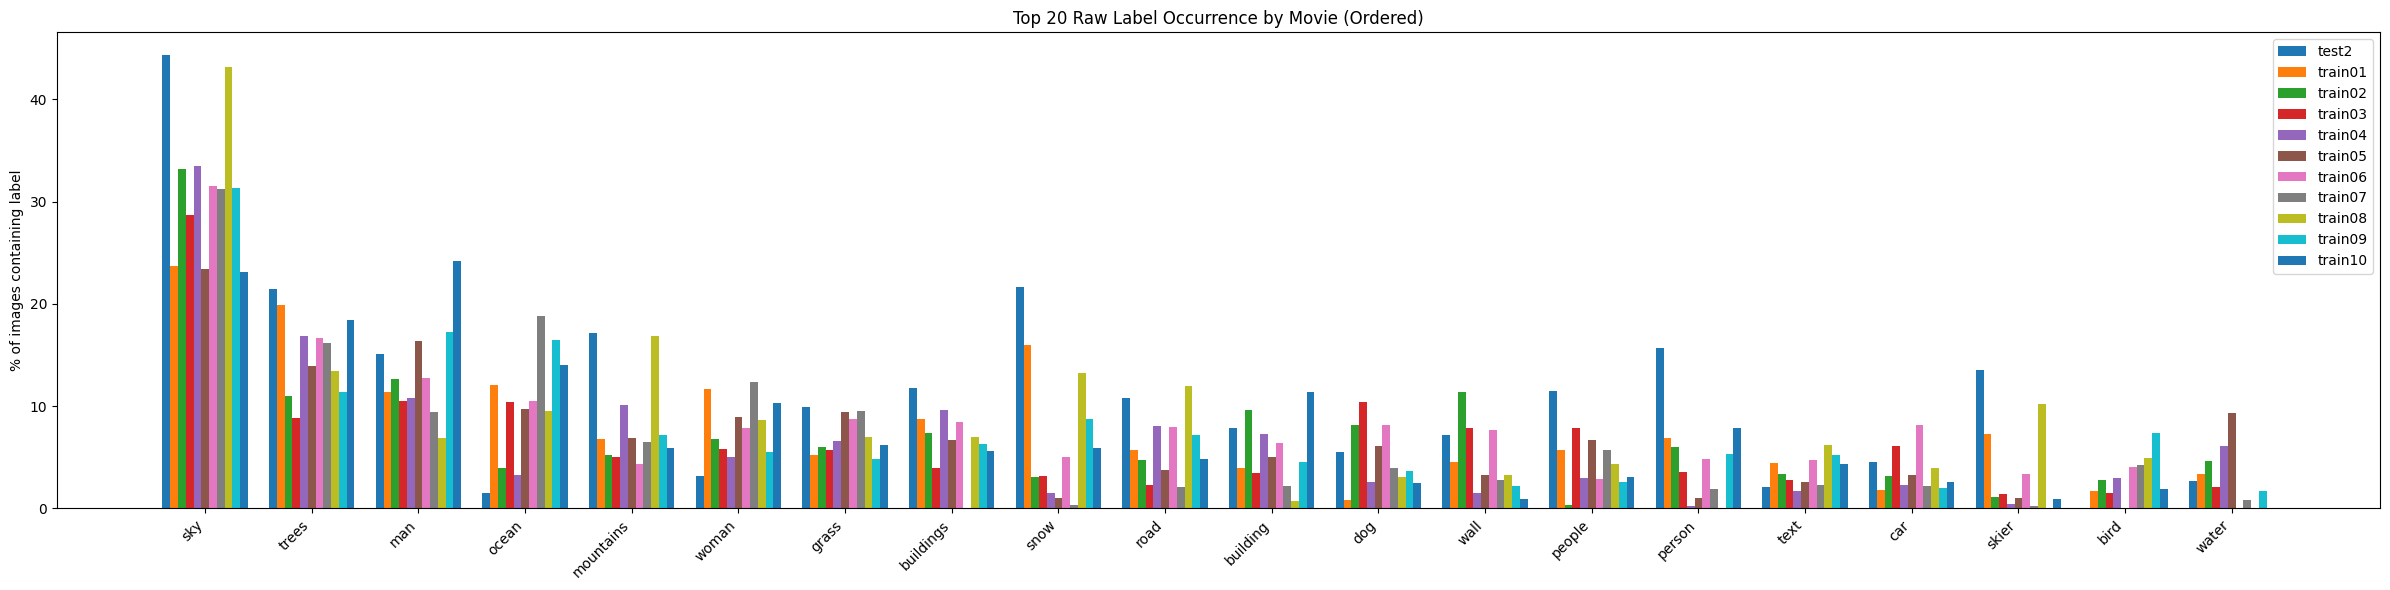

Top raw labels globally (in plotted order):
[('sky', 4977), ('trees', 2415), ('man', 2163), ('ocean', 1668), ('mountains', 1287), ('woman', 1286), ('grass', 1140), ('buildings', 1073), ('snow', 1069), ('road', 984), ('building', 905), ('dog', 803), ('wall', 752), ('people', 743), ('person', 716), ('text', 590), ('car', 580), ('skier', 509), ('bird', 476), ('water', 457)]


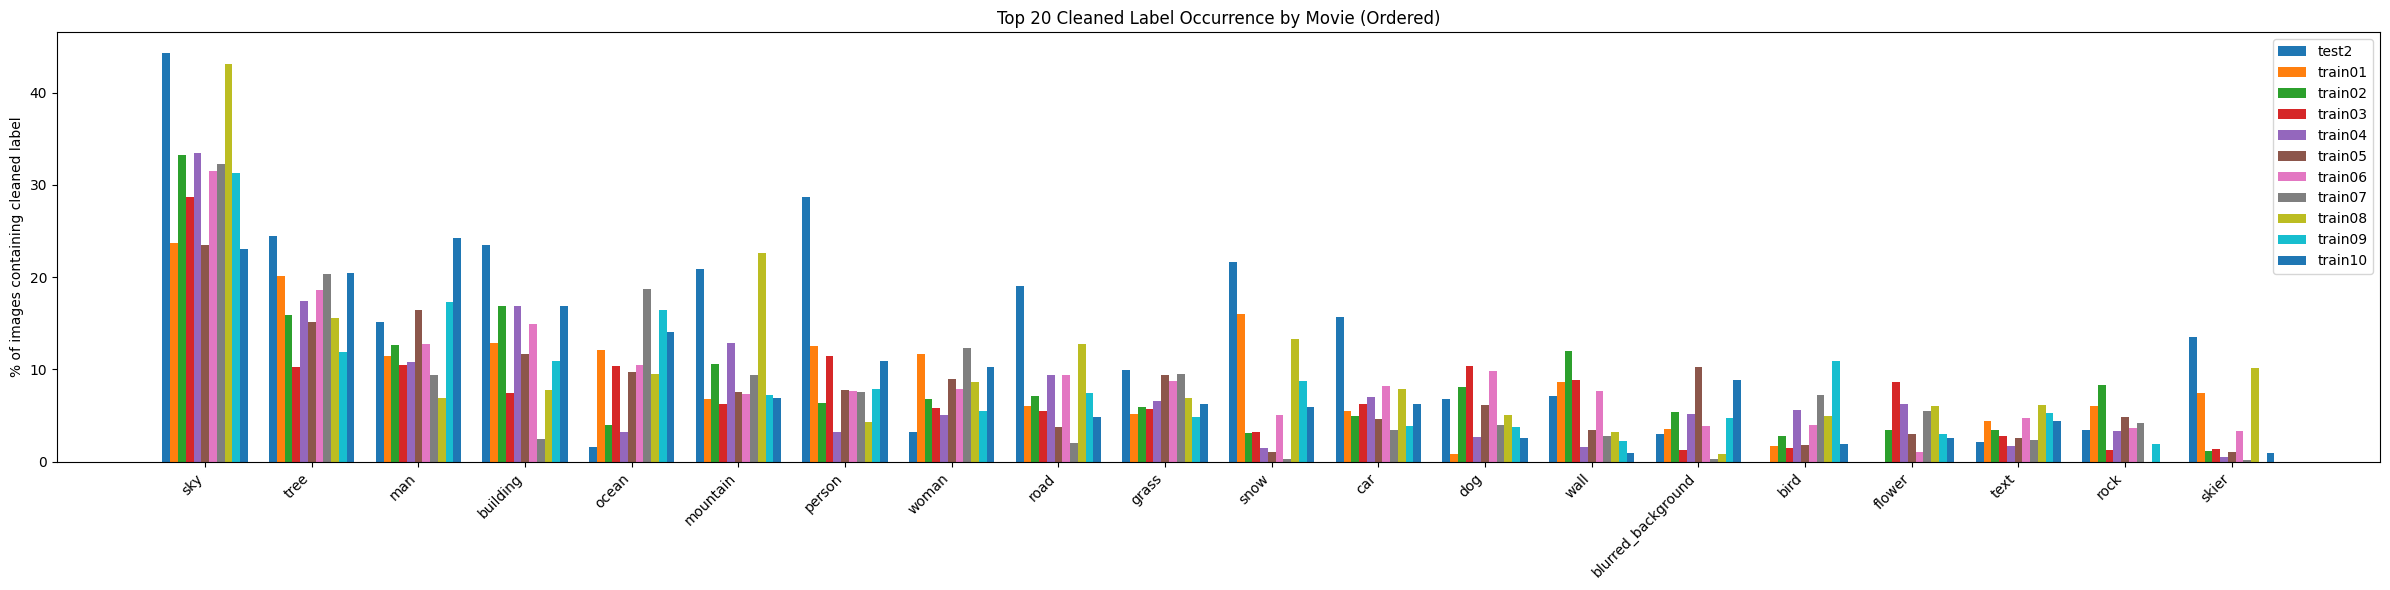

Top cleaned labels globally (in plotted order):
[('sky', 4992), ('tree', 2730), ('man', 2163), ('building', 2018), ('ocean', 1668), ('mountain', 1658), ('person', 1474), ('woman', 1287), ('road', 1204), ('grass', 1140), ('snow', 1069), ('car', 1016), ('dog', 868), ('wall', 839), ('blurred_background', 709), ('bird', 642), ('flower', 594), ('text', 590), ('rock', 541), ('skier', 511)]


In [26]:
# Plot the most common raw labels across all movies (top 20), ordered by global frequency.
def parse_movie_raw_label_counts(xml_path: Path) -> Counter:
    tree = ET.parse(xml_path)
    root = tree.getroot()
    label_counts = Counter()

    for image in root.findall('.//image'):
        labels_in_image = set()
        for mask in image.findall('.//mask'):
            label = mask.get('label')
            if label is not None and label != '':
                labels_in_image.add(label)
        label_counts.update(labels_in_image)

    return label_counts

# get the raw label counts per movie
movie_raw_label_counts = {
    movie: parse_movie_raw_label_counts(xml_dir / f"{movie}.xml")
    for movie in movies
}

# then aggregate globally to find top labels for plotting
global_label_counts = Counter()
for counts in movie_raw_label_counts.values():
    global_label_counts.update(counts)

top_n = 20
top_labels = [label for label, _ in global_label_counts.most_common(top_n)]

# number of images per movie for percentage normalization.
movie_totals = {
    movie: len(ET.parse(xml_dir / f"{movie}.xml").getroot().findall(".//image"))
    for movie in movies
}

# Raw-label grouped bar plot in exact frequency order.
x = np.arange(len(top_labels))
width = 0.8 / max(len(movies), 1)

_, ax = plt.subplots(figsize=(max(14, len(top_labels) * 1.2), 6))
for i, movie in enumerate(movies):
    total = max(movie_totals[movie], 1)
    pct = [100 * movie_raw_label_counts[movie].get(label, 0) / total for label in top_labels]
    ax.bar(x + i * width, pct, width, label=movie)

ax.set_xticks(x + width * (len(movies) - 1) / 2)
ax.set_xticklabels(top_labels, rotation=45, ha="right")
ax.set_ylabel("% of images containing label")
ax.set_title(f"Top {top_n} Raw Label Occurrence by Movie (Ordered)")
ax.legend()
plt.tight_layout()
plt.show()

print("Top raw labels globally (in plotted order):")
print(global_label_counts.most_common(top_n))

# Build cleaned per-movie counts using label_map, then plot the cleaned bar plot.
# label_map = load_python_dict(label_map_path, "label_map")

movie_cleaned_label_counts = {}
for movie in movies:
    cleaned_counts = Counter()
    for raw_label, count in movie_raw_label_counts[movie].items():
        cleaned_label = label_map.get(raw_label, raw_label)
        if cleaned_label:
            cleaned_counts[cleaned_label] += count
    movie_cleaned_label_counts[movie] = cleaned_counts

global_cleaned_label_counts = Counter()
for counts in movie_cleaned_label_counts.values():
    global_cleaned_label_counts.update(counts)

top_cleaned_n = 20
top_cleaned_labels = [
    label for label, _ in global_cleaned_label_counts.most_common(top_cleaned_n)
]

x_clean = np.arange(len(top_cleaned_labels))
_, ax = plt.subplots(figsize=(max(14, len(top_cleaned_labels) * 1.2), 6))
for i, movie in enumerate(movies):
    total = max(movie_totals[movie], 1)
    pct = [
        100 * movie_cleaned_label_counts[movie].get(label, 0) / total
        for label in top_cleaned_labels
    ]
    ax.bar(x_clean + i * width, pct, width, label=movie)

ax.set_xticks(x_clean + width * (len(movies) - 1) / 2)
ax.set_xticklabels(top_cleaned_labels, rotation=45, ha="right")
ax.set_ylabel("% of images containing cleaned label")
ax.set_title(f"Top {top_cleaned_n} Cleaned Label Occurrence by Movie (Ordered)")
ax.legend() 
plt.tight_layout()
plt.show()

print("Top cleaned labels globally (in plotted order):")
print(global_cleaned_label_counts.most_common(top_cleaned_n))

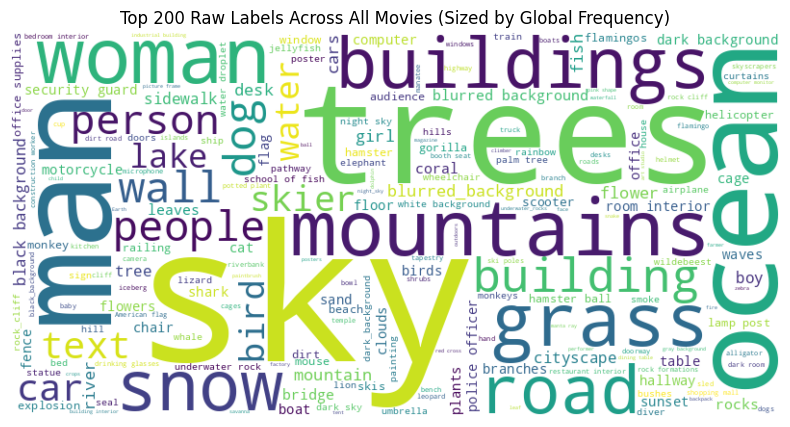

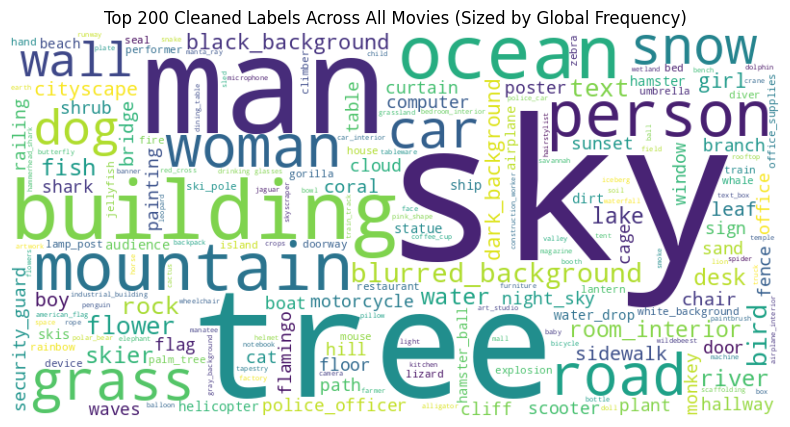

In [27]:
# Get the top labels and their global frequencies
top_labels = [label for label, _ in global_label_counts.most_common(600)]
label_frequencies = {label: global_label_counts[label] for label in top_labels}

# Generate the wordcloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(label_frequencies)

# Display the wordcloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Top 200 Raw Labels Across All Movies (Sized by Global Frequency)')
plt.show()

# label_map = load_python_dict(label_map_path, 'label_map')

# make a wordcloud for the top labels across all movies for the cleaned labels (after mapping to corrected labels using label_map), sized by global frequency.
# Get the top cleaned labels and their global frequencies
cleaned_label_counts = Counter()
for movie in movies:
    for label, count in movie_raw_label_counts[movie].items():
        cleaned_label = label_map.get(label)
        if cleaned_label is not None:
            cleaned_label_counts[cleaned_label] += count
top_cleaned_labels = [label for label, _ in cleaned_label_counts.most_common(600)]
cleaned_label_frequencies = {label: cleaned_label_counts[label] for label in top_cleaned_labels}

# Generate the wordcloud for cleaned labels
cleaned_wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(cleaned_label_frequencies)
# Display the cleaned wordcloud
plt.figure(figsize=(10, 5))
plt.imshow(cleaned_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Top 200 Cleaned Labels Across All Movies (Sized by Global Frequency)')
plt.show()



cool, that makes sense. now let's look at the masks for some images?

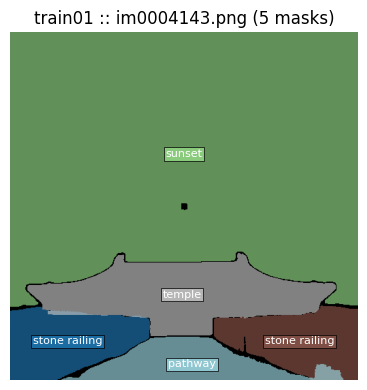

In [28]:
# Plot XML masks for one frame on a black 512x512 canvas with per-mask labels.
movie = "train01"
image_selector = "im0004143.png"  # use image filename or integer image id

xml_path = xml_dir / f"{movie}.xml"
tree = ET.parse(xml_path)
root = tree.getroot()

def decode_cvat_rle(rle_text: str, width: int, height: int) -> np.ndarray:
    counts = [int(v.strip()) for v in rle_text.split(",") if v.strip()]
    flat = np.zeros(width * height, dtype=np.uint8)
    idx = 0
    value = 0  # CVAT RLE starts with background run length

    for count in counts:
        end = min(idx + count, flat.size)
        if value == 1 and end > idx:
            flat[idx:end] = 1
        idx = end
        value = 1 - value
        if idx >= flat.size:
            break

    return flat.reshape((height, width))

images = root.findall(".//image")
if isinstance(image_selector, int):
    image_node = next((im for im in images if int(im.get("id", "-1")) == image_selector), None)
else:
    image_node = next((im for im in images if im.get("name") == image_selector), None)

if image_node is None:
    available = [im.get("name", "") for im in images[:10]]
    raise ValueError(f"Image {image_selector!r} not found in {xml_path.name}. Sample names: {available}")

canvas_h, canvas_w = 512, 512
canvas = np.zeros((canvas_h, canvas_w, 3), dtype=float)
mask_nodes = image_node.findall("mask")

if not mask_nodes:
    print(f"No masks found for {movie} / {image_node.get('name')}")
else:
    cmap = plt.get_cmap("tab20", max(len(mask_nodes), 1))
    label_positions = []

    for i, mask_node in enumerate(mask_nodes):
        label = mask_node.get("label", "unknown")
        rle = mask_node.get("rle")
        left = int(mask_node.get("left", "0"))
        top = int(mask_node.get("top", "0"))
        width = int(mask_node.get("width", "0"))
        height = int(mask_node.get("height", "0"))

        if not rle or width <= 0 or height <= 0:
            continue

        crop_mask = decode_cvat_rle(rle, width, height).astype(bool)

        x0 = max(left, 0)
        y0 = max(top, 0)
        x1 = min(left + width, canvas_w)
        y1 = min(top + height, canvas_h)
        if x1 <= x0 or y1 <= y0:
            continue

        crop_x0 = x0 - left
        crop_y0 = y0 - top
        crop_x1 = crop_x0 + (x1 - x0)
        crop_y1 = crop_y0 + (y1 - y0)
        roi_mask = crop_mask[crop_y0:crop_y1, crop_x0:crop_x1]
        if not np.any(roi_mask):
            continue

        color = np.array(cmap(i)[:3])
        roi = canvas[y0:y1, x0:x1]
        roi[roi_mask] = 0.35 * roi[roi_mask] + 0.65 * color

        ys, xs = np.nonzero(roi_mask)
        cx = x0 + float(xs.mean())
        cy = y0 + float(ys.mean())
        label_positions.append((label, cx, cy, color))

    plt.figure(figsize=(4, 4))
    plt.imshow(canvas)
    for label, cx, cy, color in label_positions:
        plt.text(
            cx,
            cy,
            label,
            color="white",
            fontsize=8,
            ha="center",
            va="center",
            bbox={
                "facecolor": (color[0], color[1], color[2], 0.75),
                "edgecolor": "black",
                "linewidth": 0.5,
                "pad": 1.2,
            },
        )

    plt.title(f"{movie} :: {image_node.get('name')} ({len(label_positions)} masks)")
    plt.xlim(0, 511)
    plt.ylim(511, 0)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

cool, now let's make OHE 

In [29]:
def build_binary_design_matrix(xml_path: Path, resolver) -> pd.DataFrame:
    """create a binary design matrix with rows as images and columns as features, 
    where a 1 indicates the presence of a feature in that image according to the masks. 
    The resolver function maps raw mask labels to desired feature names, 
    allowing for label normalization or grouping.
    """

    tree = ET.parse(xml_path)
    root = tree.getroot()
    rows = {}

    for image in root.findall('.//image'):
        image_name = image.get('name', image.get('id', 'unknown'))
        features = set()
        for mask in image.findall('.//mask'):
            raw_label = mask.get('label')
            feature = resolver(raw_label)
            if feature is not None:
                features.add(feature)
        rows[image_name] = features

    all_features = sorted({f for features in rows.values() for f in features})
    if not rows:
        return pd.DataFrame()

    df = pd.DataFrame(
        {
            image_name: {feature: int(feature in features) for feature in all_features}
            for image_name, features in rows.items()
        }
    ).T
    df.index.name = 'image'
    return df

In [30]:
movie_files = {movie: xml_dir / f'{movie}.xml' for movie in movies}

missing_xml = [movie for movie, path in movie_files.items() if not path.exists()]
if missing_xml:
    raise FileNotFoundError(f'Missing XML files: {missing_xml}')

movie_totals = {}

def normalized_label_resolver(raw_label: str | None):
    if raw_label is None:
        return 'unlabeled'
    return label_map.get(raw_label)

label_design_matrices = {
    movie: build_binary_design_matrix(path, normalized_label_resolver)
    for movie, path in movie_files.items()
}

In [31]:
# get all of the labels across the entire movie set
all_normalized_labels = sorted({
    label
    for dm in label_design_matrices.values()
    for label in dm.columns
})

# reindex each design matrix to have the same columns (all normalized labels), filling missing columns with 0s
label_design_matrices = {
    movie: dm.reindex(columns=all_normalized_labels, fill_value=0)
    for movie, dm in label_design_matrices.items()
}


# downsample to a TR so we can make our features!
downsampled_label_design_matrices = {
    movie: downsample_design_matrix(dm, step=10)
    for movie, dm in label_design_matrices.items()
}


print('Normalized-label design matrix shapes:')
for movie in movies:
    full_shape = label_design_matrices[movie].shape
    down_shape = downsampled_label_design_matrices[movie].shape
    print(f"  {movie}: full={full_shape}, downsampled={down_shape}")

# save downsampled_label_design_matrices as features, "visual_20260315_corrected-labels"
labelstosave = {}
for movie, df in downsampled_label_design_matrices.items():
    print(df.values.shape)
    featurewords = df.columns.tolist()
    labelstosave[movie] = df.values

np.savez('/hehe/projects/gaze-corrected-semantics/jen_reference/data/features/visual_segmented-objects.npz', **labelstosave)
np.save('/hehe/projects/gaze-corrected-semantics/jen_reference/data/features/visual_segmented-objects_featurewords.npy',featurewords)


Normalized-label design matrix shapes:
  test2: full=(907, 578), downsampled=(91, 578)
  train01: full=(1478, 578), downsampled=(148, 578)
  train02: full=(1524, 578), downsampled=(153, 578)
  train03: full=(1497, 578), downsampled=(150, 578)
  train04: full=(1479, 578), downsampled=(148, 578)
  train05: full=(1603, 578), downsampled=(161, 578)
  train06: full=(1492, 578), downsampled=(150, 578)
  train07: full=(1497, 578), downsampled=(150, 578)
  train08: full=(1453, 578), downsampled=(146, 578)
  train09: full=(1563, 578), downsampled=(157, 578)
  train10: full=(1577, 578), downsampled=(158, 578)
(91, 578)
(148, 578)
(153, 578)
(150, 578)
(148, 578)
(161, 578)
(150, 578)
(150, 578)
(146, 578)
(157, 578)
(158, 578)


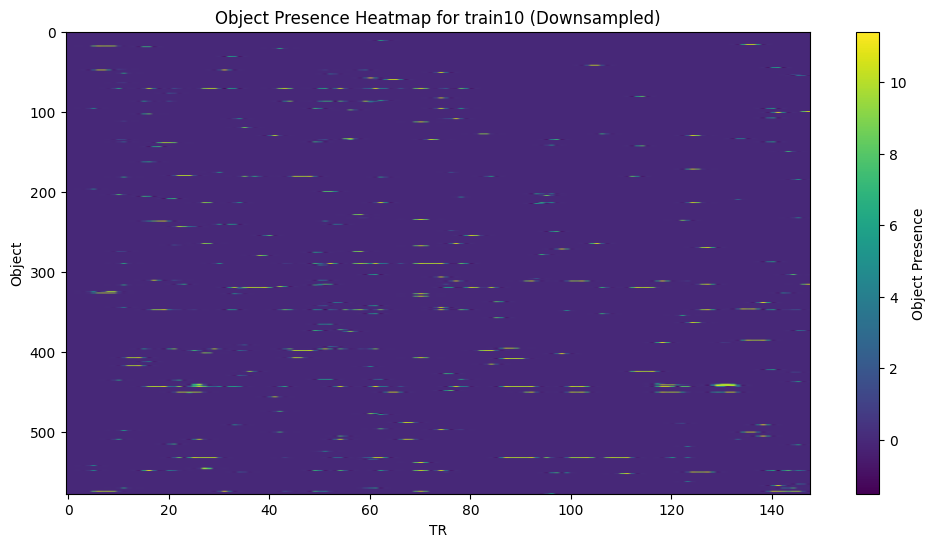

In [32]:
# imshow the downsampled design matrix for one movie to verify it looks correct
plt.figure(figsize=(12,6))
plt.imshow(downsampled_label_design_matrices['train01'].values.T, aspect='auto', cmap='viridis')
plt.colorbar(label='Object Presence')
plt.title(f'Object Presence Heatmap for {movie} (Downsampled)')
plt.xlabel('TR')
plt.ylabel('Object')
plt.show()
plt.close()

# okay NOW let's add eyetracking to it, and save out the features for ZXI and KLR

In [33]:
def get_fixation_labels(
    experiment: str,
    subject: str,
    session: str,
    movie_list: list[str],
    results_by_movie: dict,
    label_map_lookup: dict,
):
    if experiment == 'report-attn':
        gaze_data = load_reportattn_eyetracking(
            subject,
            session,
            runtype=None,
            makefivetwelve=True,
        )
    elif experiment == 'psychedelic':
        gaze_data = load_psychedelic_eyetracking(
            subject,
            session,
            runtype=None,
            makefivetwelve=True,
        )
    else:
        raise ValueError(f'Unknown experiment: {experiment}')

    def run_key_to_movie_key(run_key: str) -> str:
        """Map gaze-corrected run keys to base movie names used by mask XMLs.

        Examples:
        - test2match03_run-01 -> test2
        - train01match -> train01
        """
        m = re.match(r'(test\d+)(?:impmatch|match|ecprod|rest)(?:\d+)?(?:_run-\d+)?$', run_key)
        if m:
            return m.group(1)

        m = re.match(r'train(\d+)(?:impmatch|match|ecprod|rest)?(?:_run-\d+)?$', run_key)
        if m:
            return f"train{int(m.group(1)):02d}"

        m = re.match(r'trn(\d+)(?:impmatch|match|ecprod|rest)?(?:_run-\d+)?$', run_key)
        if m:
            return f"train{int(m.group(1)):02d}"

        m = re.match(r'(test\d+)(?:_run-\d+)?$', run_key)
        if m:
            return m.group(1)

        return re.sub(r'(impmatch|match|ecprod|rest)$', '', run_key)

    fixation_tables = {}
    fixation_label_lookup = {}

    for run_key in movie_list:
        if run_key not in gaze_data:
            print(f'Skipping {run_key}: missing eyetracking run')
            continue

        movie_name = run_key_to_movie_key(run_key)
        if movie_name not in results_by_movie:
            print(f'Skipping {run_key}: could not map to available movie masks ({movie_name})')
            continue

        images = results_by_movie[movie_name]
        gaze_df = gaze_data[run_key]
        aligned_xy = align_gaze_to_frames(gaze_df, len(images))

        fixation_df = extract_fixation_point_labels(
            movie_name=movie_name,
            images=images,
            aligned_xy=aligned_xy,
            label_map_lookup=label_map_lookup,
        )
        fixation_df['source_run'] = run_key

        outkey = run_key if experiment == 'report-attn' else movie_name
        print(outkey)
        fixation_tables[outkey] = fixation_df
        fixation_label_lookup[outkey] = dict(
            zip(fixation_df['frame_idx'], fixation_df['normalized_label'])
        )

    return fixation_label_lookup, fixation_tables


In [34]:
# Keep effective maps as direct copies so entry counts stay stable across notebook cells.
from segmentation import load_movie_annotations

label_map = {str(k).strip(): str(v).strip() for k, v in label_map.items()}

results, together, setofwords = load_movie_annotations(movies, xml_dir=str(xml_dir))

print('Movies loaded for fixation extraction:', len(results))
print('Number of original labels (includes plurals, etc):', len(label_map))


Loaded 907 frames for 'test2' with 135 unique labels.
Loaded 1478 frames for 'train01' with 221 unique labels.
Loaded 1524 frames for 'train02' with 203 unique labels.
Loaded 1497 frames for 'train03' with 147 unique labels.
Loaded 1479 frames for 'train04' with 138 unique labels.
Loaded 1603 frames for 'train05' with 158 unique labels.
Loaded 1492 frames for 'train06' with 188 unique labels.
Loaded 1497 frames for 'train07' with 170 unique labels.
Loaded 1453 frames for 'train08' with 144 unique labels.
Loaded 1563 frames for 'train09' with 144 unique labels.
Loaded 1577 frames for 'train10' with 186 unique labels.
Movies loaded for fixation extraction: 11
Number of original labels (includes plurals, etc): 825


In [ ]:

subject = 'KLR'
session = 'match'
experiment = 'report-attn'

# get moives from get_report-attn_eyetracking, bc thoseh are the actual gaze-corrected runs
# that we need to match to the masks. 

actualmovies = set()
actualmoviedata = load_reportattn_eyetracking(subject, session, runtype=None)
print(actualmoviedata.keys())

actualmovies = actualmoviedata.keys()


Found session directories: ['/hehe/data/preproc/01_mri-bids/GOOD_DATA/report-attn-eyetracking/sub-KLR/ses-report03/', '/hehe/data/preproc/01_mri-bids/GOOD_DATA/report-attn-eyetracking/sub-KLR/ses-report02/']
dict_keys(['test2match03_run-01', 'test2match03_run-02', 'train09match', 'train02match', 'train06match', 'train01match', 'train10match', 'train03match', 'test2match02_run-01', 'train04match', 'train07match', 'train08match', 'train05match', 'test2match02_run-02'])


In [ ]:

# fixations_match, fixation_tables = get_fixation_labels(
#     experiment=experiment,
#     subject=subject,
#     session=session,
#     movie_list=actualmovies,
#     results_by_movie=results,
#     label_map_lookup=label_map,
# )

# # fixations_rest, fixation_tables_rest = get_fixation_labels(
# #     experiment='report-attn',
# #     subject=subject,
# #     session='rest',
# #     movie_list=movies,
# #     results_by_movie=results,
# #     label_map_lookup=label_map,
# # )


Found session directories: ['/hehe/data/preproc/01_mri-bids/GOOD_DATA/report-attn-eyetracking/sub-KLR/ses-report03/', '/hehe/data/preproc/01_mri-bids/GOOD_DATA/report-attn-eyetracking/sub-KLR/ses-report02/']
test2match03_run-01
test2match03_run-02
train09match
train02match
train06match
train01match
train10match
train03match
test2match02_run-01
train04match
train07match
train08match
train05match
test2match02_run-02


In [54]:

def get_report_gaze_corrected_semantics(
    subject: str,
    results: dict,
    effective_label_map: dict[str, str],
    effective_category_map: dict[str, str],
    FIXATION_WEIGHT: float = 3.0,
    FIXATION_WEIGHT_MODE: str = 'multiply',
    data_dir: str = '/hehe/projects/gaze-corrected-semantics/jen_reference/data',
):
    """Create gaze-corrected semantic features for report-attn runs.

    This uses run-level fixation outputs from get_fixation_labels, maps each run key
    to its base movie design matrix, applies fixation weighting, downsamples, and saves.
    """

    def run_key_to_movie_key(run_key: str) -> str:
        m = re.match(r'(test\d+)(?:impmatch|match|ecprod|rest)(?:\d+)?(?:_run-\d+)?$', run_key)
        if m:
            return m.group(1)

        m = re.match(r'train(\d+)(?:impmatch|match|ecprod|rest)?(?:_run-\d+)?$', run_key)
        if m:
            return f"train{int(m.group(1)):02d}"

        m = re.match(r'trn(\d+)(?:impmatch|match|ecprod|rest)?(?:_run-\d+)?$', run_key)
        if m:
            return f"train{int(m.group(1)):02d}"

        m = re.match(r'(test\d+)(?:_run-\d+)?$', run_key)
        if m:
            return m.group(1)

        return re.sub(r'(impmatch|match|ecprod|rest)$', '', run_key)

    def fixation_targets(label: str, columns: pd.Index) -> list[str]:
        if not isinstance(label, str) or label == '':
            return []

        targets = []

        # Most runs already provide normalized labels that should match matrix columns.
        if label in columns:
            targets.append(label)

        # Fallback to explicit label map and category map if needed.
        mapped_label = effective_label_map.get(label, label)
        if mapped_label in columns and mapped_label not in targets:
            targets.append(mapped_label)

        mapped_category = effective_category_map.get(mapped_label, effective_category_map.get(label))
        if isinstance(mapped_category, str) and mapped_category in columns and mapped_category not in targets:
            targets.append(mapped_category)

        return targets

    def apply_fixation_weight_to_label_features(
        label_matrices: dict[str, pd.DataFrame],
        fixation_lookup: dict[str, dict[int, str]],
        weight: float = 3.0,
        mode: str = 'multiply',
    ) -> dict[str, pd.DataFrame]:
        weighted = {}

        for run_key, frame_to_label in fixation_lookup.items():
            movie_key = run_key_to_movie_key(run_key)
            if movie_key not in label_matrices:
                print(f"Skipping {run_key}: no base movie matrix for {movie_key}")
                continue

            dm = label_matrices[movie_key].copy()
            n_rows = dm.shape[0]

            for frame_idx, label in frame_to_label.items():
                if frame_idx < 0 or frame_idx >= n_rows:
                    continue

                targets = fixation_targets(label, dm.columns)
                if not targets:
                    continue

                for col in targets:
                    if mode == 'multiply':
                        dm.iat[frame_idx, dm.columns.get_loc(col)] *= weight
                    elif mode == 'add':
                        dm.iat[frame_idx, dm.columns.get_loc(col)] += weight
                    elif mode == 'replace':
                        dm.iat[frame_idx, dm.columns.get_loc(col)] = weight
                    else:
                        raise ValueError(f"Unsupported FIXATION_WEIGHT_MODE: {mode}")

            weighted[run_key] = dm

        return weighted

    # Use actual available run keys per condition so report-attn test runs are included.
    match_run_keys = sorted(load_reportattn_eyetracking(subject, 'match', runtype=None).keys())
    rest_run_keys = sorted(load_reportattn_eyetracking(subject, 'rest', runtype=None).keys())

    fixations_match, _ = get_fixation_labels(
        experiment='report-attn',
        subject=subject,
        session='match',
        movie_list=match_run_keys,
        results_by_movie=results,
        label_map_lookup=effective_label_map,
    )

    fixations_rest, _ = get_fixation_labels(
        experiment='report-attn',
        subject=subject,
        session='rest',
        movie_list=rest_run_keys,
        results_by_movie=results,
        label_map_lookup=effective_label_map,
    )

    weighted_label_design_matrices_match = apply_fixation_weight_to_label_features(
        label_matrices=label_design_matrices,
        fixation_lookup=fixations_match,
        weight=FIXATION_WEIGHT,
        mode=FIXATION_WEIGHT_MODE,
    )

    weighted_label_design_matrices_rest = apply_fixation_weight_to_label_features(
        label_matrices=label_design_matrices,
        fixation_lookup=fixations_rest,
        weight=FIXATION_WEIGHT,
        mode=FIXATION_WEIGHT_MODE,
    )

    # keep run-level keys (e.g., train01match, test2match03_run-01, etc.)
    weighted_label_design_matrices = {
        **weighted_label_design_matrices_match,
        **weighted_label_design_matrices_rest,
    }

    weighted_downsampled_label_design_matrices = {
        run_key: downsample_design_matrix(dm, step=10)
        for run_key, dm in weighted_label_design_matrices.items()
    }

    weighted_label_out = Path(data_dir) / 'features' / f'visual_{subject}-gaze-corrected-semantics.npz'
    weighted_label_words_out = Path(data_dir) / 'features' / f'visual_{subject}-gaze-corrected-semantics_featurewords.npy'

    weighted_payload = {run_key: dm.values for run_key, dm in weighted_downsampled_label_design_matrices.items()}

    # for any run keys that have two digits after match or rest, remove digits to create a more general key (e.g., test2match03_run-01 -> test2match_run-01)
    for run_key in list(weighted_payload.keys()):
        new_key = re.sub(r'(test\d+)(impmatch|match|ecprod|rest)\d+(_run-\d+)?$', r'\1\2\3', run_key)
        if new_key != run_key and new_key not in weighted_payload:
            weighted_payload[new_key] = weighted_payload[run_key]
            print(f"Added general key {new_key} for {run_key}")
            # remove old key to avoid confusion, since the more specific key is already included
            del weighted_payload[run_key]

    if len(weighted_downsampled_label_design_matrices) == 0:
        raise RuntimeError('No weighted design matrices were created.')

    first_key = next(iter(weighted_downsampled_label_design_matrices.keys()))
    weighted_feature_words = weighted_downsampled_label_design_matrices[first_key].columns.tolist()

    for run_key in list(weighted_downsampled_label_design_matrices.keys()):
        new_key = re.sub(r'(test\d+)(impmatch|match|ecprod|rest)\d+(_run-\d+)?$', r'\1\2\3', run_key)
        if new_key != run_key and new_key not in weighted_downsampled_label_design_matrices:
            weighted_downsampled_label_design_matrices[new_key] = weighted_downsampled_label_design_matrices[run_key]
            print(f"Added general key {new_key} for {run_key}")
            del weighted_downsampled_label_design_matrices[run_key]

    print('Saving weighted label features to:', weighted_label_out)
    np.savez(weighted_label_out, **weighted_payload)
    print('Saving weighted label feature words to:', weighted_label_words_out)
    np.save(weighted_label_words_out, weighted_feature_words)

    return weighted_downsampled_label_design_matrices


In [59]:
# Run gaze-corrected semantic feature generation for one subject and print saved run keys.
weighted_run_matrices = get_report_gaze_corrected_semantics(
    subject='ZXI',
    results=results,
    effective_label_map=label_map,
    effective_category_map={},
    FIXATION_WEIGHT=3.0,
    FIXATION_WEIGHT_MODE='multiply',
)

print('Run keys saved:', len(weighted_run_matrices))
for k in sorted(weighted_run_matrices.keys()):
    print(' ', k, weighted_run_matrices[k].shape)

Found session directories: ['/hehe/data/preproc/01_mri-bids/GOOD_DATA/report-attn-eyetracking/sub-ZXI/ses-report03/', '/hehe/data/preproc/01_mri-bids/GOOD_DATA/report-attn-eyetracking/sub-ZXI/ses-report01/', '/hehe/data/preproc/01_mri-bids/GOOD_DATA/report-attn-eyetracking/sub-ZXI/ses-report02/']
Found session directories: ['/hehe/data/preproc/01_mri-bids/GOOD_DATA/report-attn-eyetracking/sub-ZXI/ses-report03/', '/hehe/data/preproc/01_mri-bids/GOOD_DATA/report-attn-eyetracking/sub-ZXI/ses-report01/', '/hehe/data/preproc/01_mri-bids/GOOD_DATA/report-attn-eyetracking/sub-ZXI/ses-report02/']
Found session directories: ['/hehe/data/preproc/01_mri-bids/GOOD_DATA/report-attn-eyetracking/sub-ZXI/ses-report03/', '/hehe/data/preproc/01_mri-bids/GOOD_DATA/report-attn-eyetracking/sub-ZXI/ses-report01/', '/hehe/data/preproc/01_mri-bids/GOOD_DATA/report-attn-eyetracking/sub-ZXI/ses-report02/']
test2match01_run-01
test2match01_run-02
test2match02_run-01
test2match02_run-02
test2match03_run-01
test2m

In [60]:
matrixtoviz = np.load('/hehe/projects/gaze-corrected-semantics/jen_reference/data/features/visual_ZXI-gaze-corrected-semantics.npz')['train01match']

In [61]:
old = np.load('/hehe/projects/report-attn/data/features/visual_ZXI-gaze-corrected-semantics.npz', allow_pickle=True)['train01match']
old.shape

(148, 578)

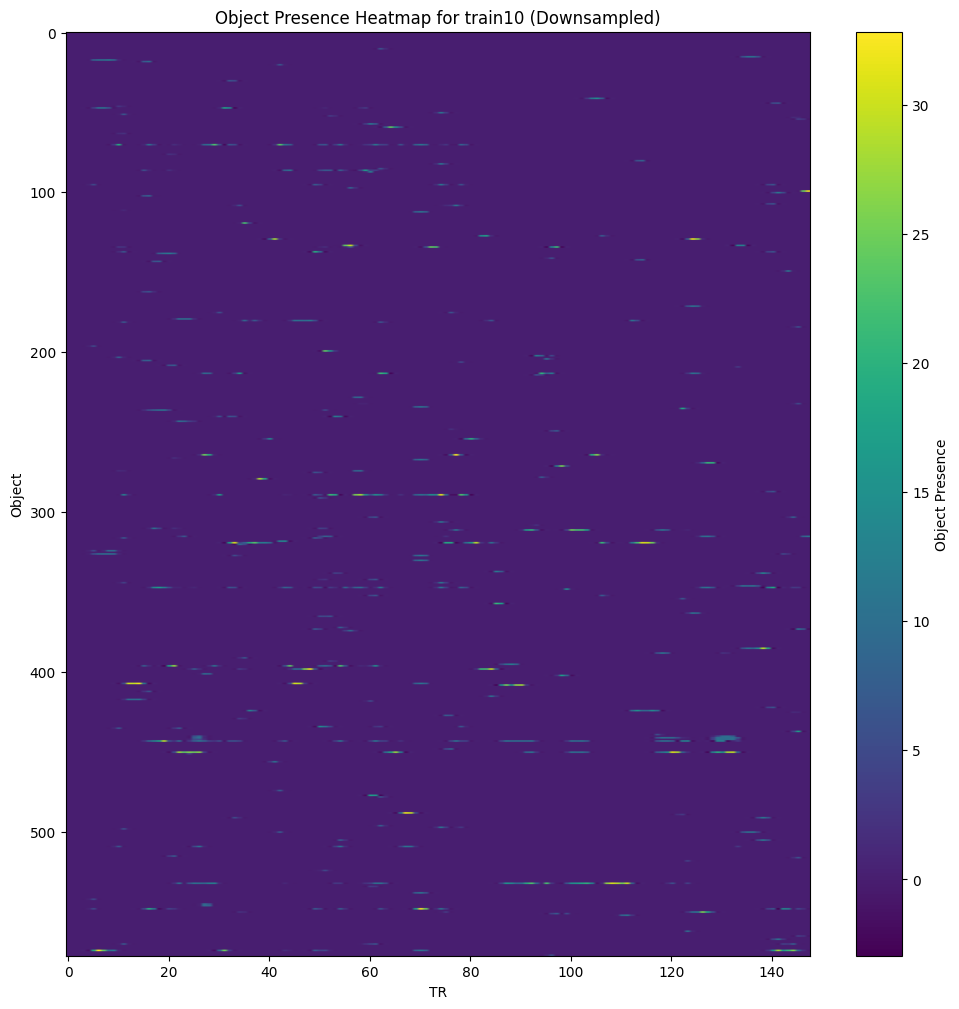

In [66]:
# imshow the downsampled design matrix for one movie to verify it looks correct
plt.figure(figsize=(12,12))
plt.imshow(matrixtoviz.T, aspect='auto', cmap='viridis')
plt.colorbar(label='Object Presence')
plt.title(f'Object Presence Heatmap for {movie} (Downsampled)')
plt.xlabel('TR')
plt.ylabel('Object')
plt.show()
plt.close()